# RoBERTA on agnews
### LLM data generation: **"Llama-2-7b-chat-hf"**

https://huggingface.co/FacebookAI/roberta-base  
https://huggingface.co/FacebookAI/roberta-large

- total number of train samples: 500
- total number of test&nbsp; samples: 500
- classification model: "roberta-large"
- dataset: agnews

Generation methods:
- **A** generic augmentation
- **B** targeted augmentation
- **C** unsupervised context augmentation

TESTS:
1. 500 real
2. 250 real + 250 synthetic (A, B, C)
3. 50 real + 450 synthetic (A, B, C)
4. 500 synthetic (A, B, C)
5. 500 real data with generated labels in zero-shot settings

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import json
from sklearn.model_selection import train_test_split

# CHANGE WORKING DIRECTORY TO ROOT
current_dir = os.path.basename(os.getcwd())
if current_dir == "src":
    os.chdir("..") # Move up by 1
elif os.path.basename(os.getcwd()) == "bai-thesis-nlp":  
    pass # If already at root, stay there
else:
    os.chdir("../..") # Move up by 2 otherwise
     
from src._utils._helpers import get_generated_examples_df
from src._utils._run_multiclassRoBERTA import main_multiclassRoBERTA

In [2]:
LLM_NAME = "Llama-2-7b-chat-hf"
DATASET_NAME = "agnews"
FOLDER_DIR = "src/"+DATASET_NAME+"/experiments/RoBERTA_500samples/data_"+LLM_NAME
os.makedirs(FOLDER_DIR, exist_ok=True)
LOG_DIR = os.path.join(FOLDER_DIR, "RoBERTA_log.json")

### LOAD DATA ###
# real data
real_train_df = pd.read_csv("real_data/train/"+DATASET_NAME+"trainAll.csv").rename(columns={"2": "text", "3": "label"})
real_train_df.drop(columns=["0", "1"], inplace=True)

# Take 500 samples for dev set
real_train_df, dev_df = train_test_split(real_train_df, test_size=500, random_state=42, stratify=real_train_df["label"])
# Store the dev set into a CSV file
dev_df.to_csv(os.path.join(FOLDER_DIR, "dev_set.csv"), index=False)

# synthetic data (generic, targeted and unsupervised context)
SYNTHETIC_DATA_DIR = "synthetic_data/datasets/"+LLM_NAME+"/"
syn_generic_df, _ = get_generated_examples_df(SYNTHETIC_DATA_DIR+DATASET_NAME+"_baseline_500.json")
syn_targeted_df, _ = get_generated_examples_df(SYNTHETIC_DATA_DIR+DATASET_NAME+"_targeted+tags_500.json")
syn_targeted_df = syn_targeted_df.drop(columns=["phenomena"], inplace=False)
syn_unsupContext_df, _ = get_generated_examples_df(SYNTHETIC_DATA_DIR+DATASET_NAME+"_unsupervisedContext_500.json")
syn_unsupContext_df = syn_unsupContext_df.drop(columns=["context_examples"])
# zeroshot data (real data + zeroshot generated labels)
data = "./src/"+DATASET_NAME+"/experiments/fewshotCasualLM_500samples/fewshot_llama2_zeroshot.csv"
zeroshot_df = pd.read_csv(data)

results = []

In [3]:
def get_results(details):
    """Just get useful results from the details"""
    res = details["metrics_dev"]
    res["method"] = details["experiment_dir"].split("/")[-1].replace("exp_", "")
    res["train_time"] = details["train_time"]
    res["eval_time"] = details["eval_time"]
    
    df = pd.DataFrame([res])
    new_order = ["method"] + [col for col in df.columns if col != "method"]
    df = df[new_order]
    display(df.round(3))
    return df

In [4]:
base_config = {
    "real_df": real_train_df,
    # "synth_df": None/syn_generic_df..,
    "dev_df": dev_df,
    # "synth_ratio": 0.0/0.5..,
    "max_samples": 500,
    "epochs": 8,
    "batch_size": 16,
    # "output_dir": os.path.join(FOLDER_DIR, name),
    "log_dir": LOG_DIR,
    # "generation_method": None/"generic"/"targeted",
    "save_model": False,
    "save_dataset": True,
}

## 1. 500 real

In [5]:
name = "exp_500real"
config = base_config.copy()
config["synth_df"] = None
config["synth_ratio"] = 0.0
config["output_dir"] = os.path.join(FOLDER_DIR, name)
config["generation_method"] = None

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,0.917500,0.308777,0.900000,0.839651,0.900000
2,0.225300,0.450190,0.892000,0.827020,0.892000
3,0.194200,0.368562,0.920000,0.877516,0.920000
4,0.085200,0.543847,0.912000,0.863132,0.912000
5,0.034300,0.481854,0.926000,0.889001,0.926000
6,0.023200,0.506654,0.920000,0.877706,0.920000
7,0.015100,0.492994,0.926000,0.890811,0.926000
8,0.010500,0.494258,0.926000,0.890811,0.926000


,method,f1_micro,f1_macro,accuracy,train_time,eval_time
0,500real,0.926,0.889,0.926,193.721,4.107


## 2. 250 real + 250 synthetic

A. Generic augmentation

In [6]:
name = "exp_250real_250generic"
config = base_config.copy()
config["synth_df"] = syn_generic_df # Generic Augmentation
config["synth_ratio"] = 0.5 # 50% of the data is synthetic
config["output_dir"] = os.path.join(FOLDER_DIR, name)
config["generation_method"] = "generic augmentation"

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,1.073900,0.393597,0.868000,0.761348,0.868000
2,0.246200,0.287358,0.918000,0.876357,0.918000
3,0.075200,0.454831,0.916000,0.874757,0.916000
4,0.052700,0.450721,0.918000,0.880820,0.918000
5,0.008900,0.546309,0.908000,0.870821,0.908000
6,0.001700,0.573612,0.902000,0.853309,0.902000
7,0.000600,0.587475,0.912000,0.875010,0.912000
8,0.000500,0.583694,0.914000,0.877130,0.914000


,method,f1_micro,f1_macro,accuracy,train_time,eval_time
0,250real_250generic,0.918,0.876,0.918,190.605,4.134


B. Targeted augmentation

In [7]:
name = "exp_250real_250targeted"
config = base_config.copy()
config["synth_df"] = syn_targeted_df # Targeted Augmentation
config["synth_ratio"] = 0.5 # 50% of the data is synthetic
config["output_dir"] = os.path.join(FOLDER_DIR, name)
config["generation_method"] = "targeted augmentation"

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,0.888500,0.352744,0.904000,0.841442,0.904000
2,0.225500,0.378066,0.884000,0.807919,0.884000
3,0.078200,0.468421,0.902000,0.858959,0.902000
4,0.023300,0.605821,0.894000,0.850938,0.894000
5,0.001000,0.641314,0.906000,0.858145,0.906000
6,0.001700,0.614450,0.914000,0.876000,0.914000
7,0.000500,0.623454,0.910000,0.869587,0.910000
8,0.000400,0.629395,0.912000,0.871690,0.912000


,method,f1_micro,f1_macro,accuracy,train_time,eval_time
0,250real_250targeted,0.914,0.876,0.914,191.103,4.099


C. Unsupervised Context augmentation

In [8]:
name = "exp_250real_250unsupContext"
config = base_config.copy()
config["synth_df"] = syn_unsupContext_df # Unsupervised Context Augmentation
config["synth_ratio"] = 0.5 # 50% of the data is synthetic
config["output_dir"] = os.path.join(FOLDER_DIR, name)
config["generation_method"] = "unsupervised context"

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,0.882400,0.321955,0.898000,0.852514,0.898000
2,0.291600,0.388659,0.896000,0.846398,0.896000
3,0.129100,0.428835,0.888000,0.849454,0.888000
4,0.079200,0.620842,0.874000,0.835396,0.874000
5,0.043700,0.562758,0.902000,0.856233,0.902000
6,0.023600,0.556403,0.902000,0.856424,0.902000
7,0.015300,0.561516,0.900000,0.856162,0.900000
8,0.009900,0.571818,0.898000,0.855348,0.898000


,method,f1_micro,f1_macro,accuracy,train_time,eval_time
0,250real_250unsupContext,0.902,0.856,0.902,192.732,4.121


## 3. 50 real + 450 synthetic
A. Generic augmentation

In [9]:
name = "exp_50real_450generic"
config = base_config.copy()
config["synth_df"] = syn_generic_df # Generic Augmentation
config["synth_ratio"] = 0.9 # 90% of the data is synthetic
config["output_dir"] = os.path.join(FOLDER_DIR, name)
config["generation_method"] = "generic augmentation"

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,0.995700,0.703780,0.760000,0.748073,0.760000
2,0.151000,0.428115,0.852000,0.802189,0.852000
3,0.056800,1.186572,0.754000,0.704805,0.754000
4,0.022700,0.581828,0.866000,0.810588,0.866000
5,0.001300,0.662727,0.856000,0.789628,0.856000
6,0.000400,0.698969,0.856000,0.789628,0.856000
7,0.000400,0.705790,0.856000,0.789628,0.856000
8,0.000300,0.708808,0.856000,0.789628,0.856000


,method,f1_micro,f1_macro,accuracy,train_time,eval_time
0,50real_450generic,0.866,0.811,0.866,191.83,4.115


B. Targeted augmentation

In [10]:
name = "exp_50real_450targeted"
config = base_config.copy()
config["synth_df"] = syn_targeted_df # Targeted Augmentation
config["synth_ratio"] = 0.9 # 90% of the data is synthetic
config["output_dir"] = os.path.join(FOLDER_DIR, name)
config["generation_method"] = "targeted augmentation"

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,0.674600,0.973063,0.602000,0.550911,0.602000
2,0.099900,0.434066,0.868000,0.810757,0.868000
3,0.018600,0.624173,0.850000,0.782304,0.850000
4,0.001600,0.608322,0.876000,0.818907,0.876000
5,0.000500,0.741558,0.862000,0.788957,0.862000
6,0.000400,0.755642,0.862000,0.788957,0.862000
7,0.000300,0.749282,0.862000,0.788957,0.862000
8,0.000300,0.750605,0.864000,0.790923,0.864000


,method,f1_micro,f1_macro,accuracy,train_time,eval_time
0,50real_450targeted,0.876,0.819,0.876,191.91,4.109


C. Unsupervised Context augmentation

In [11]:
name = "exp_50real_450unsupContext"
config = base_config.copy()
config["synth_df"] = syn_unsupContext_df # Unsupervised Context Augmentation
config["synth_ratio"] = 0.9 # 90% of the data is synthetic
config["output_dir"] = os.path.join(FOLDER_DIR, name)
config["generation_method"] = "unsupervised context"

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,0.783800,0.979977,0.644000,0.606849,0.644000
2,0.175000,0.955772,0.692000,0.649118,0.692000
3,0.142800,0.907084,0.768000,0.738194,0.768000
4,0.060400,1.119634,0.770000,0.718272,0.770000
5,0.014800,1.034927,0.782000,0.729903,0.782000
6,0.005100,1.411341,0.740000,0.686358,0.740000
7,0.001400,1.254361,0.770000,0.715077,0.770000
8,0.000800,1.225410,0.776000,0.719860,0.776000


,method,f1_micro,f1_macro,accuracy,train_time,eval_time
0,50real_450unsupContext,0.782,0.73,0.782,192.208,4.104


## 4. 500 synthetic
A. Generic augmentation

In [12]:
name = "exp_500generic"
config = base_config.copy()
config["real_df"] = None
config["synth_df"] = syn_generic_df # Generic Augmentation
config["synth_ratio"] = 1.0 # 100% of the data is synthetic
config["output_dir"] = os.path.join(FOLDER_DIR, name)
config["generation_method"] = "generic augmentation"
config["save_dataset"] = False

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,0.707500,1.630981,0.494000,0.499539,0.494000
2,0.035100,2.847602,0.558000,0.533334,0.558000
3,0.001300,2.736336,0.592000,0.573155,0.592000
4,0.000500,2.799565,0.596000,0.584575,0.596000
5,0.000300,2.926577,0.594000,0.582149,0.594000
6,0.000300,3.008534,0.592000,0.577795,0.592000
7,0.000300,3.040484,0.592000,0.577795,0.592000
8,0.000300,3.053042,0.592000,0.576731,0.592000


,method,f1_micro,f1_macro,accuracy,train_time,eval_time
0,500generic,0.596,0.585,0.596,190.465,4.108


B. Targeted augmentation

In [13]:
name = "exp_500targeted"
config = base_config.copy()
config["real_df"] = None
config["synth_df"] = syn_targeted_df # Targeted Augmentation
config["synth_ratio"] = 1.0 # 100% of the data is synthetic
config["output_dir"] = os.path.join(FOLDER_DIR, name)
config["generation_method"] = "targeted augmentation"
config["save_dataset"] = False

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,0.687400,1.498175,0.584000,0.553579,0.584000
2,0.024400,2.022113,0.658000,0.644385,0.658000
3,0.001400,3.106901,0.596000,0.551640,0.596000
4,0.012200,3.434765,0.580000,0.535459,0.580000
5,0.000300,3.522064,0.584000,0.535172,0.584000
6,0.000200,3.478341,0.590000,0.541805,0.590000
7,0.000200,3.494537,0.590000,0.541805,0.590000
8,0.000200,3.501045,0.590000,0.541805,0.590000


,method,f1_micro,f1_macro,accuracy,train_time,eval_time
0,500targeted,0.658,0.644,0.658,191.11,4.098


C. Unsupervised Context augmentation

In [14]:
name = "exp_500unsupContext"
config = base_config.copy()
config["real_df"] = None
config["synth_df"] = syn_unsupContext_df # Unsupervised Context Augmentation
config["synth_ratio"] = 1.0 # 100% of the data is synthetic
config["output_dir"] = os.path.join(FOLDER_DIR, name)
config["generation_method"] = "unsupervised context"
config["save_dataset"] = False

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,0.666800,1.442550,0.628000,0.607911,0.628000
2,0.133000,2.130946,0.628000,0.587879,0.628000
3,0.081900,2.252286,0.546000,0.541173,0.546000
4,0.037300,2.209955,0.646000,0.611524,0.646000
5,0.032500,2.924713,0.626000,0.585165,0.626000
6,0.006700,2.762350,0.616000,0.564818,0.616000
7,0.002100,2.738350,0.628000,0.583173,0.628000
8,0.000900,2.822193,0.616000,0.566955,0.616000


,method,f1_micro,f1_macro,accuracy,train_time,eval_time
0,500unsupContext,0.646,0.612,0.646,192.285,4.11


## 5. 500 real data with generated labels in zero-shot settings

In [15]:
display(zeroshot_df.head())
print("accuracy:", round(sum(zeroshot_df['label'] == zeroshot_df['predicted_label']) / len(zeroshot_df), 3))

# keep only the labels that are allowed
labels = zeroshot_df['label'].unique()
zeroshot_df = zeroshot_df[zeroshot_df["predicted_label"].isin(labels)].reset_index(drop=True)
print("new accuracy:", round(sum(zeroshot_df['label'] == zeroshot_df['predicted_label']) / len(zeroshot_df), 3))

# set the predicted label as the real label for training
zeroshot_df['label'] = zeroshot_df["predicted_label"]
zeroshot_df = zeroshot_df.drop(columns=["predicted_label"])

print("number of samples:", zeroshot_df.shape[0])

,text,label,predicted_label
0,"NEW DELHI, SEPTEMBER 17: The Cabinet today app...",World,World
1,In LONDON story headlined quot;Van Nistelrooy...,Sports,World
2,A new report from Congress #39; research arm a...,Business,Business
3,The head of the U.N. nuclear watchdog agency s...,World,Sci/Tech
4,A years-long phenomenon continues as crowds ga...,Sci/Tech,Sci/Tech.


accuracy: 0.656
new accuracy: 0.708
number of samples: 463


In [16]:
name = "exp_500real_zeroshotLabel"
config = base_config.copy()
# the data is real, but the labels are predicted in zero-shot setting
config["real_df"] = zeroshot_df
config["synth_df"] = None
config["synth_ratio"] = 0.0
config["output_dir"] = os.path.join(FOLDER_DIR, name)
config["generation_method"] = "real data with zero-shot labels"
config["save_dataset"] = False

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,1.214500,0.744114,0.630000,0.604583,0.630000
2,0.735100,0.431284,0.846000,0.815789,0.846000
3,0.516100,0.643371,0.778000,0.740207,0.778000
4,0.380300,0.864493,0.772000,0.740927,0.772000
5,0.249700,1.091106,0.744000,0.707931,0.744000
6,0.124400,1.329354,0.734000,0.696738,0.734000
7,0.083100,1.561792,0.728000,0.691443,0.728000
8,0.049100,1.621346,0.726000,0.688841,0.726000


,method,f1_micro,f1_macro,accuracy,train_time,eval_time
0,500real_zeroshotLabel,0.846,0.816,0.846,185.016,4.112



---
# Results

In [17]:
df_results = pd.concat(results).reset_index(drop=True)
df_results.to_csv(os.path.join(FOLDER_DIR, "RoBERTA_results_dev.csv"), index=False)
display(df_results.round(3))

,method,f1_micro,f1_macro,accuracy,train_time,eval_time
0,500real,0.926,0.889,0.926,193.721,4.107
1,250real_250generic,0.918,0.876,0.918,190.605,4.134
2,250real_250targeted,0.914,0.876,0.914,191.103,4.099
3,250real_250unsupContext,0.902,0.856,0.902,192.732,4.121
4,50real_450generic,0.866,0.811,0.866,191.830,4.115
5,50real_450targeted,0.876,0.819,0.876,191.910,4.109
6,50real_450unsupContext,0.782,0.730,0.782,192.208,4.104
7,500generic,0.596,0.585,0.596,190.465,4.108
8,500targeted,0.658,0.644,0.658,191.110,4.098
9,500unsupContext,0.646,0.612,0.646,192.285,4.110


In [9]:
df_results = pd.read_csv(os.path.join(FOLDER_DIR, "RoBERTA_results_dev.csv"))

display(df_results.round(3))

,method,f1_micro,f1_macro,accuracy,train_time,eval_time
0,500real,0.926,0.889,0.926,193.721,4.107
1,250real_250generic,0.918,0.876,0.918,190.605,4.134
2,250real_250targeted,0.914,0.876,0.914,191.103,4.099
3,250real_250unsupContext,0.902,0.856,0.902,192.732,4.121
4,50real_450generic,0.866,0.811,0.866,191.830,4.115
5,50real_450targeted,0.876,0.819,0.876,191.910,4.109
6,50real_450unsupContext,0.782,0.730,0.782,192.208,4.104
7,500generic,0.596,0.585,0.596,190.465,4.108
8,500targeted,0.658,0.644,0.658,191.110,4.098
9,500unsupContext,0.646,0.612,0.646,192.285,4.110


In [ ]:
import pandas as pd

# Define a function to extract fields
def split_method(m):
    # Check for special case
    if 'zeroshotLabel' in m:
        return pd.Series([m, 'zeroshotLabel'])
    elif 'generic' in m:
        config = m.replace('generic', 'synthetic')
        return pd.Series([config, 'generic'])
    elif 'targeted' in m:
        config = m.replace('targeted', 'synthetic')
        return pd.Series([config, 'targeted'])
    elif 'unsupContext' in m:
        config = m.replace('unsupContext', 'synthetic')
        return pd.Series([config, 'unsupContext'])
    elif 'real' in m and '_' not in m:
        return pd.Series([m, 'real'])
    else:
        return pd.Series([m, 'unknown'])

# Apply the function
df_results[['configuration', 'generation_method']] = df_results['method'].apply(split_method)

display(df_results)

,method,f1_micro,f1_macro,accuracy,train_time,eval_time,configuration,generation_method
0,500real,0.926,0.889001,0.926,193.720601,4.106574,500real,real
1,250real_250generic,0.918,0.876357,0.918,190.604834,4.134197,250real_250synthetic,generic
2,250real_250targeted,0.914,0.876000,0.914,191.103439,4.099271,250real_250synthetic,targeted
3,250real_250unsupContext,0.902,0.856233,0.902,192.731640,4.120923,250real_250synthetic,unsupContext
4,50real_450generic,0.866,0.810588,0.866,191.830285,4.114819,50real_450synthetic,generic
5,50real_450targeted,0.876,0.818907,0.876,191.910236,4.108849,50real_450synthetic,targeted
6,50real_450unsupContext,0.782,0.729903,0.782,192.208002,4.103534,50real_450synthetic,unsupContext
7,500generic,0.596,0.584575,0.596,190.465190,4.107991,500synthetic,generic
8,500targeted,0.658,0.644385,0.658,191.109947,4.098146,500synthetic,targeted
9,500unsupContext,0.646,0.611524,0.646,192.285037,4.109699,500synthetic,unsupContext


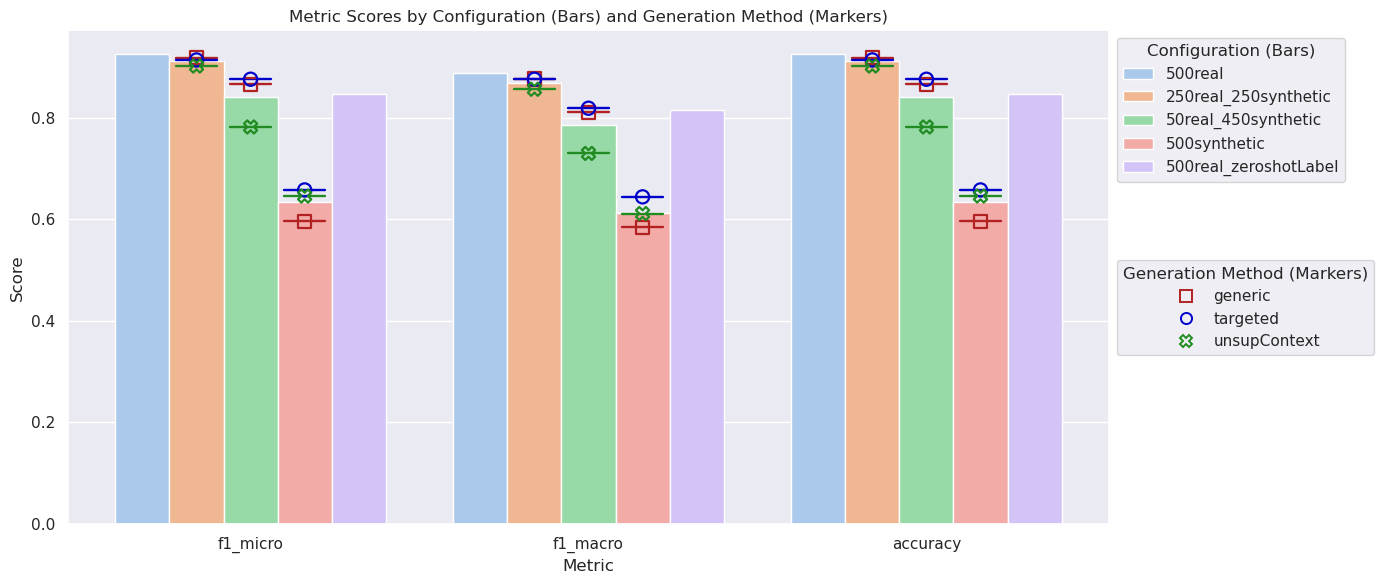

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

# Set style
sns.set_style("darkgrid")


# Melt the data to long format
df_long = df_results.melt(
    id_vars=["configuration", "generation_method"],
    value_vars=["f1_micro", "f1_macro", "accuracy"],
    var_name="metric",
    value_name="score"
)

# Set the figure
plt.figure(figsize=(14, 6))

# Create a grouped barplot
barplot = sns.barplot(
    data=df_long,
    x="metric",
    y="score",
    hue="configuration",
    errorbar=None,
    palette="pastel"
)

# Compute positions of bars to align dots
metric_order = df_long['metric'].unique()
config_order = df_long['configuration'].unique()
group_width = 0.8
n_configs = len(config_order)
bar_width = group_width / n_configs

# Compute x positions for bars
x_positions = {}
for i, metric in enumerate(metric_order):
    for j, config in enumerate(config_order):
        x = i - group_width/2 + j * bar_width + bar_width / 2
        x_positions[(metric, config)] = x

# Define marker styles for generation methods
marker_styles = {
    # 'real': ('d', 'black'),
    'generic': ('s', 'firebrick'),
    'targeted': ('o', 'mediumblue'),
    'unsupContext': ('X', 'forestgreen'),
    # 'zeroshotLabel': ('^', 'orange')
}


# Only plot dots for selected generation methods
excluded_methods = ['real', 'zeroshotLabel']

for _, row in df_long.iterrows():
    if row['generation_method'] in excluded_methods:
        continue  # skip plotting for real and zeroshotLabel

    x = x_positions[(row['metric'], row['configuration'])]
    marker, edge_color = marker_styles[row['generation_method']]
    plt.scatter(
        x, row['score'],
        facecolors='none',
        edgecolors=edge_color,
        marker=marker,
        s=90,
        linewidth=1.6,
        zorder=5
    )
    tick_width = 0.06
    plt.plot([x - tick_width, x + tick_width], [row['score'], row['score']], color=edge_color, lw=1.7, zorder=4)


# Custom legend (excluding real and zeroshotLabel)
scatter_handles = [
    Line2D([0], [0], marker=m, color=c, label=label, markerfacecolor='none',
           markeredgewidth=1.4, markersize=8, linestyle='None')
    for label, (m, c) in marker_styles.items() if label not in excluded_methods
]


# Plot customization
plt.title("Metric Scores by Configuration (Bars) and Generation Method (Markers)")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.xticks(ticks=range(len(metric_order)), labels=metric_order)

# Legends
bar_handles, bar_labels = barplot.get_legend_handles_labels()
legend1 = plt.legend(bar_handles, bar_labels, title='Configuration (Bars)', loc='upper left', bbox_to_anchor=(1, 1))
plt.legend(scatter_handles, marker_styles.keys(), title='Generation Method (Markers)', loc='upper left', bbox_to_anchor=(1, 0.55))
plt.gca().add_artist(legend1)

plt.tight_layout()
plt.show()
